In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\delta\\Predictive-maintenence-iot\\dataset\\ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
type_mapping = {
    'L':1,
    'M':2,
    'H':3
}
df['Type_numeric'] = df['Type'].map(type_mapping)
df[['Type','Type_numeric']].head()

,Type,Type_numeric
0,M,2
1,L,1
2,L,1
3,L,1
4,L,1


In [4]:
context_failure = df[
    [
        'Type_numeric',
        'Air temperature [K]',
        'Process temperature [K]',
        'Machine failure'
    ]
]
context_failure.corr()

,Type_numeric,Air temperature [K],Process temperature [K],Machine failure
Type_numeric,1.000000,-0.015176,-0.012101,-0.036715
Air temperature [K],-0.015176,1.000000,0.876107,0.082556
Process temperature [K],-0.012101,0.876107,1.000000,0.035946
Machine failure,-0.036715,0.082556,0.035946,1.000000


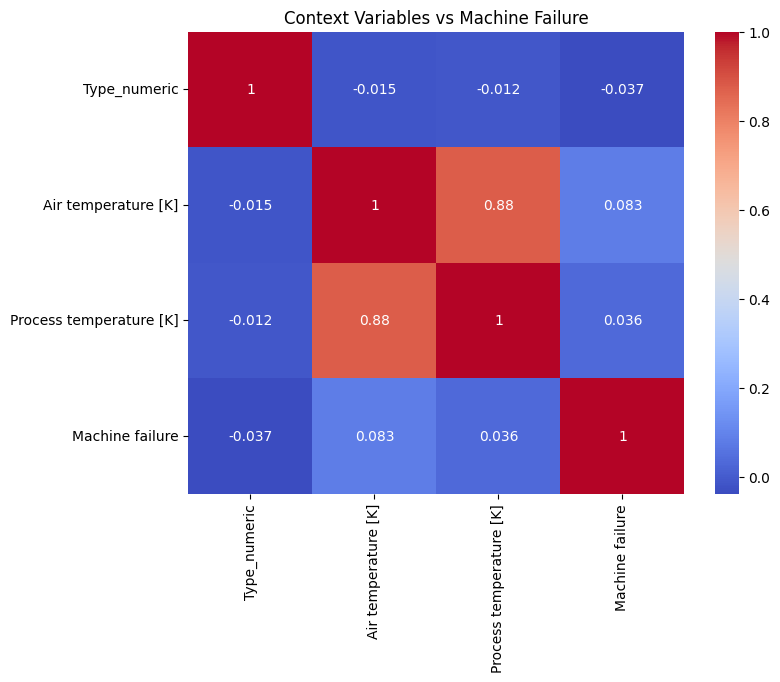

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(
    context_failure.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Context Variables vs Machine Failure")
plt.savefig("context_vs_failure_heatmap.png")
plt.show()

In [6]:
context_sensor = df[
    [
        'Type_numeric',
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]'
    ]
]
context_sensor.corr()

,Type_numeric,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Type_numeric,1.000000,-0.015176,-0.012101,-0.003979,-0.003097,-0.007255
Air temperature [K],-0.015176,1.000000,0.876107,0.022670,-0.013778,0.013853
Process temperature [K],-0.012101,0.876107,1.000000,0.019277,-0.014061,0.013488
Rotational speed [rpm],-0.003979,0.022670,0.019277,1.000000,-0.875027,0.000223
Torque [Nm],-0.003097,-0.013778,-0.014061,-0.875027,1.000000,-0.003093
Tool wear [min],-0.007255,0.013853,0.013488,0.000223,-0.003093,1.000000


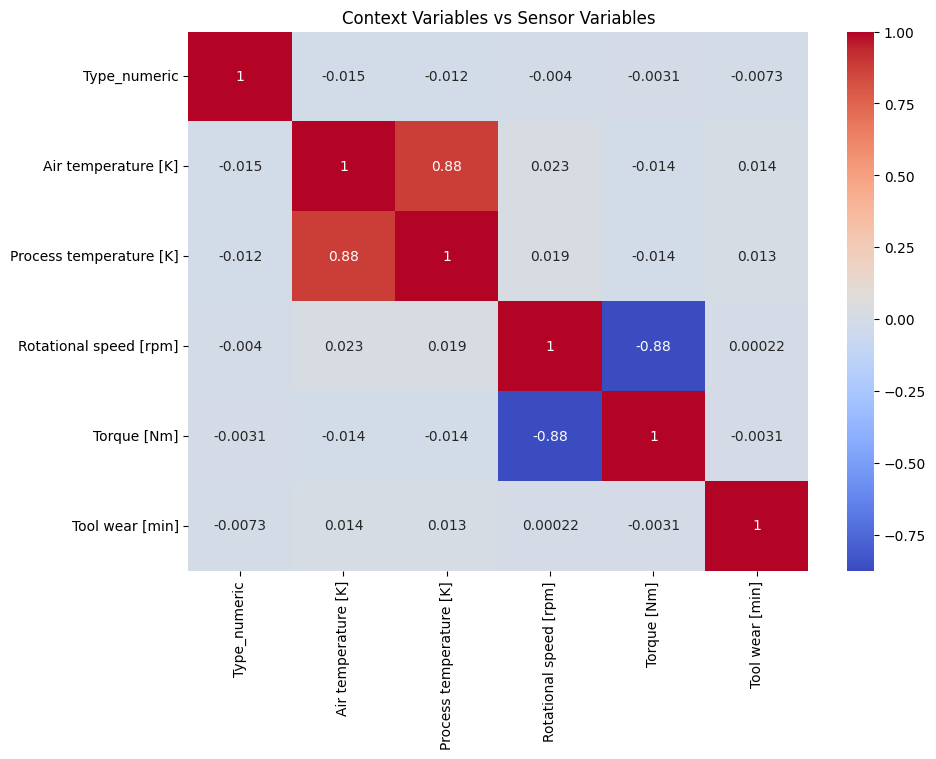

In [7]:
plt.figure(figsize=(10,7))
sns.heatmap(
    context_sensor.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Context Variables vs Sensor Variables")
plt.savefig("context_vs_sensor_heatmap.png")
plt.show()

In [8]:
df_numeric = df.select_dtypes(include=['int64','float64'])
corr_matrix = df_numeric.corr()
corr_matrix

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_numeric
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954,0.002058
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688,-0.015176
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279,-0.012101
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088,-0.003979
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136,-0.003097
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326,-0.007255
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516,-0.036715
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970,0.010977
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706,-0.014719
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273,-0.010026


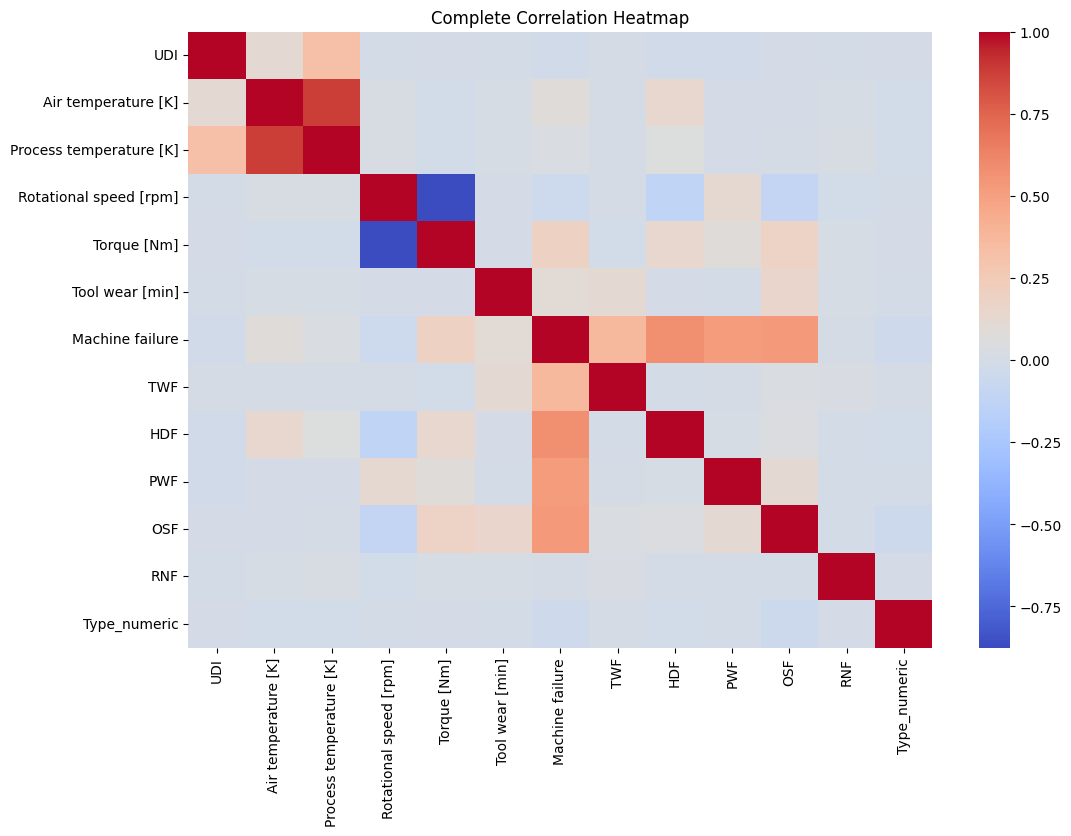

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)
plt.title("Complete Correlation Heatmap")
plt.savefig("complete_correlation_heatmap.png")
plt.show()

In [10]:
print("""
INSIGHTS

1. Machine Type shows weak correlation with machine failure.

2. Air Temperature and Process Temperature
   are strongly correlated.

3. Torque has stronger relationship with
   machine failure compared to temperature variables.

4. Tool Wear shows positive association
   with machine failure.

5. No severe multicollinearity detected.

6. Temperature variables may provide
   supporting information for prediction.
""")


INSIGHTS

1. Machine Type shows weak correlation with machine failure.

2. Air Temperature and Process Temperature
   are strongly correlated.

3. Torque has stronger relationship with
   machine failure compared to temperature variables.

4. Tool Wear shows positive association
   with machine failure.

5. No severe multicollinearity detected.

6. Temperature variables may provide
   supporting information for prediction.

